In [1]:
pwd()

'/home/mb/MEGAsync/academic_work/projects/Atomistic_continuation/code/LACT/notebooks/Cu_example'

In [1]:
# To install the repo, run (potentially pwd() needs to be adjusted)
#!pip install -e .

In [2]:
import LACT
from LACT import *

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from lammps import lammps, LMP_STYLE_ATOM, LMP_TYPE_VECTOR, LMP_TYPE_ARRAY
from ctypes import c_double, c_int

import scipy
from scipy import optimize

In [9]:
lmp_initialise = '''
# ------------------------ INITIALIZATION ----------------------------
processors    * * *
units         metal
dimension    3
boundary    p    p    p
atom_style   atomic
atom_modify map yes


box        tilt large
#--------------------------- LAMMPS Data File--------------------------
#read_data    input_data/proper_thick_domain.lmp
#read_data    input_data/thicker_domain.lmp
read_data    input_data/4b_step.lmp
change_box    all triclinic
reset_atom_ids sort yes

#--------------
pair_style    eam/alloy
pair_coeff    * * input_data/Cu_mishin1.eam.alloy Cu

#-------------------Various continuation commands----------------------
compute forces all property/atom fx fy fz
compute ids all property/atom id
compute x_check all property/atom x y z
#atom_modify map yes
'''

In [10]:
lmp = lammps(cmdargs=['-screen', 'none'])

lmp.commands_string(lmp_initialise)

In [11]:
def change_box_command(limits,direction="x"):
    command = f"""
     change_box all {direction} final {limits[0]} {limits[1]} units box
    """
    return command

def update_command_box_x(x,box_size):
    direction = "x"
    i = 0 if direction=="x" else 1 if direction=="y" else 2
    return change_box_command([box_size[0][i]+x,box_size[1][i]-x],direction=direction)

In [16]:
system = atom_cont_system(lmp,update_command_box_x)

In [17]:
system.natoms

4630

In [18]:
system.quasi_static_run(0.0, 0.05, 2, verbose=True)


        %%%%%%%%%%%%%%%%%%%%%%%%%%%
        A quasi-static run: adjust μ and minimise in LAMMPS
        
Iteration step:  1   , Solution step:  1   , Continuation parameter:  0.0
Iteration step:  2   , Solution step:  2   , Continuation parameter:  0.05


In [26]:
ds_default = 2e0
ds_smallest = 1e-3
ds_largest = 4e0

system.continuation_run(25,
                     ds_default = ds_default,
                     ds_smallest = ds_smallest,
                     ds_largest = ds_largest,
                     verbose=True)


        %%%%%%%%%%%%%%%%%%%%%%%%%%%
        A continuation run: solve extended system to find points on the solution path.
        
0:  |F(x)| = 1.09756e-05; step 1
Iteration step:  1   , Solution step:  28   , Continuation parameter:  2.227429344632514
0:  |F(x)| = 3.68996e-06; step 1
Iteration step:  2   , Solution step:  29   , Continuation parameter:  2.2759649487507825
0:  |F(x)| = 1.90497e-06; step 1
Iteration step:  3   , Solution step:  30   , Continuation parameter:  2.324505068468898
0:  |F(x)| = 0.0536739; step 1
1:  |F(x)| = 0.000486562; step 1
2:  |F(x)| = 1.59359e-05; step 1
Iteration step:  4   , Solution step:  31   , Continuation parameter:  2.3732793735303424
0:  |F(x)| = 1.62963e-06; step 1
Iteration step:  5   , Solution step:  32   , Continuation parameter:  2.4217939750081423
0:  |F(x)| = 2.54558e-06; step 1
ds doubled, now equal to  4.0 .
Iteration step:  6   , Solution step:  33   , Continuation parameter:  2.47030367522041
0:  |F(x)| = 4.79652e-06; step 1
Iter

In [28]:
path = 'dumps/thin_domain/interface_tests/'
file_name = 'dump'

In [29]:
system.dump_data(path,file_name)

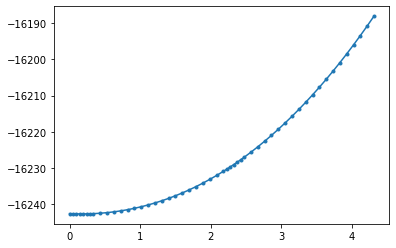

In [27]:
system.compute_energies()
μs = [Y[-1] for Y in system.data["Y_s"]]
plt.plot(μs,system.data["energies"],'.-')